In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shapely

import plotting
from transformers import TrackCellTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df_tracks = gpd.read_parquet("../data/cleaned/track_info_clustered.parquet")
df_routes = pd.read_csv("../data/raw/routes.csv")

In [3]:
df_tracks = pd.merge(df_tracks, df_routes[["route_label", "route_type", "route_name"]], on="route_label", how="left").drop(columns=["route_label"])
df_tracks['route_type'] = df_tracks['route_type'].fillna("Unknown")
df_tracks['route_name'] = df_tracks['route_name'].fillna("Unknown")

In [4]:
df_tracks.head()

,track_file,track_file_datetime,track_file_date,day_of_week,start_datetime,end_datetime,num_pauses,total_duration,active_duration,total_distance (mi),...,total_descent (m),year,season,region,start_point,end_point,track_line,route_probability,route_type,route_name
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Monday,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,0,0 days 00:48:28,0 days 00:48:28,3.060933,...,-38.079392,Freshman,Summer Training,Thompson/Davis,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215...",0.000000,Unknown,Unknown
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Tuesday,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,5,0 days 00:33:20,0 days 00:33:10,3.154848,...,-61.285231,Freshman,Summer Training,LeRoy/Great West,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ...",1.000000,Normal,Mid County Trail
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Wednesday,2019-06-12 11:53:36+00:00,2019-06-12 12:35:13+00:00,5,0 days 00:41:43,0 days 00:30:46,2.521019,...,-63.546495,Freshman,Summer Training,Thompson/Davis,POINT (-88.32153 41.91251),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32153 41.91251, -88.3215...",0.000000,Unknown,Unknown
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,Monday,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,0,0 days 00:30:00,0 days 00:30:00,2.981428,...,-42.863923,Freshman,Summer Training,Thompson/Davis,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ...",0.000000,Unknown,Unknown
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,Tuesday,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,3,0 days 00:25:23,0 days 00:25:03,2.343798,...,-46.531003,Freshman,Summer Training,LeRoy/Great West,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541...",0.903103,Normal,The Course


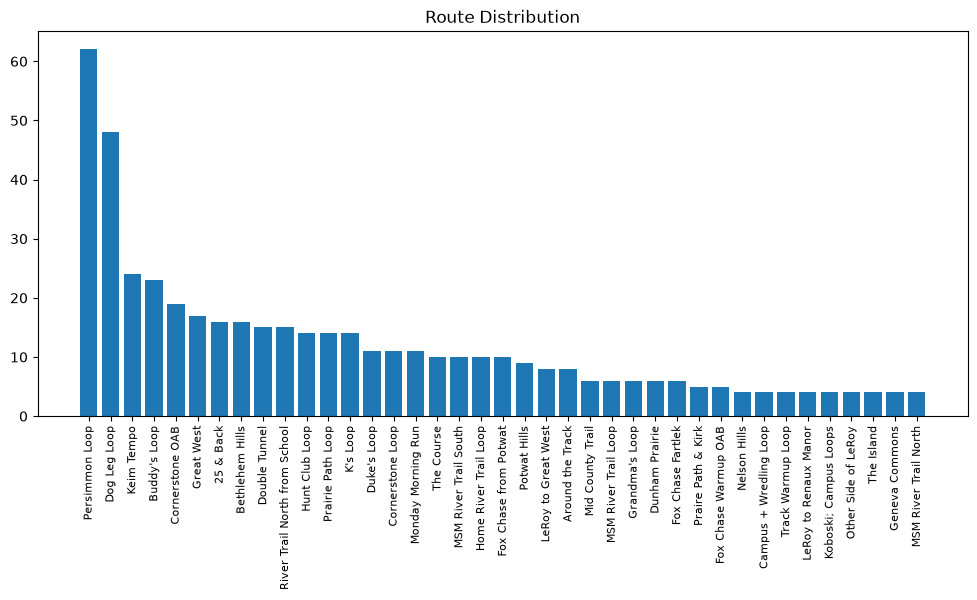

In [5]:
plt.figure(figsize=(12, 5))
plt.bar(df_tracks.loc[df_tracks['route_name'] != "Unknown", 'route_name'].value_counts().index, df_tracks.loc[df_tracks['route_name'] != "Unknown", 'route_name'].value_counts().values)
plt.xticks(rotation=90, fontsize=8)
plt.title("Route Distribution")
plt.show()

(array([ 26.,  27.,  30.,  24.,  25.,  36.,  27.,  34.,  38., 242.]),
 array([0.03610696, 0.13249627, 0.22888557, 0.32527487, 0.42166418,
        0.51805348, 0.61444279, 0.71083209, 0.80722139, 0.9036107 ,
        1.        ]),
 <BarContainer object of 10 artists>)

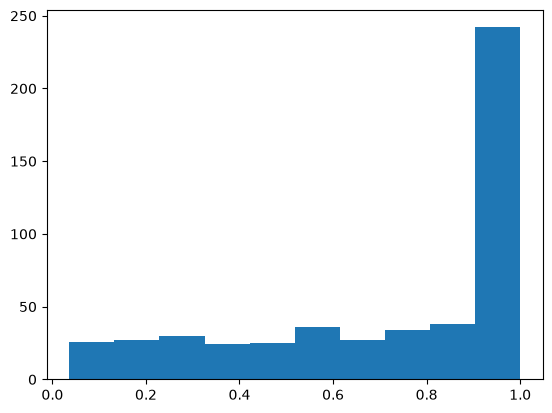

In [7]:
plt.hist(df_tracks.loc[df_tracks['route_probability'] > 0, 'route_probability'])